# Mock cosmic-variance-limited CMB likelihood with CLASS

This notebook builds a lightweight mock CMB likelihood in the spirit of MontePython's `Likelihood_mock_cmb`: generate a fiducial CMB spectrum, define an experimental multipole range and sky fraction, and evaluate the likelihood of another CLASS spectrum against the fiducial mock data.

The default setup is cosmic-variance limited: no beam, no temperature noise, no polarization noise, and no lensing reconstruction noise. The likelihood below uses the TT/TE/EE covariance matrix at each multipole and can also include the lensing-potential power spectrum `pp`. This is useful for forecasts and quick checks before setting up a full MontePython run.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from math import pi


def find_repo_root():
    here = Path.cwd().resolve()
    for path in [here, *here.parents]:
        if (path / "source").exists() and (path / "python").exists():
            return path
    return here


repo_root = find_repo_root()
cache_tag = sys.implementation.cache_tag
py_tag = f"py{sys.version_info.major}.{sys.version_info.minor}"
build_paths = [
    p.parent for p in repo_root.glob("build/lib*/classy*.so")
    if cache_tag in p.name or cache_tag in p.parent.name
]
egg_paths = [
    p for p in (repo_root / "python" / "dist").glob("classy*.egg")
    if py_tag in p.name
]
local_classy_paths = build_paths + egg_paths
for path in reversed(local_classy_paths):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import classy
from classy import Class

print("repo root:", repo_root)
print("classy imported from:\n", classy.__file__)

repo root: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_public
classy imported from:
 /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_public/build/lib.macosx-10.9-x86_64-cpython-310/classy.cpython-310-darwin.so


## Experiment definition

For a CV-limited mock experiment, the main experimental choices are `l_min`, `l_max`, the lensing-potential multipole range, and `f_sky`. The noise arrays are set to zero below, but the likelihood function accepts non-zero `N_ell` arrays if you later want to move away from the CV-limited case.

In [ ]:
experiment = {
    "name": "mock_cvl_cmb",
    "l_min": 2,
    "l_max": 6000,
    "include_lensing_pp": True,
    "l_min_pp": 2,
    "l_max_pp": 6000,
    "f_sky": 1.0,
    "lensing": "yes",
}

fiducial_cosmo = {
    "omega_b": 0.0223828,
    "omega_cdm": 0.1201075,
    "h": 0.67810,
    "A_s": 2.100549e-09,
    "n_s": 0.9660499,
    "tau_reio": 0.05430842,
}

class_settings = {
    "output": "tCl,pCl,lCl",
    "lensing": experiment["lensing"],
    "l_max_scalars": experiment["l_max"],
}

print(experiment)

{'name': 'mock_cvl_cmb', 'l_min': 2, 'l_max': 3000, 'include_lensing_pp': True, 'l_min_pp': 2, 'l_max_pp': 3000, 'f_sky': 1.0, 'lensing': 'yes'}


## CLASS wrapper and TT/TE/EE + lensing likelihood

For each multipole, define

$$C_l = \begin{pmatrix} C_l^{TT} + N_l^{TT} & C_l^{TE} \\ C_l^{TE} & C_l^{EE} + N_l^{EE} \end{pmatrix}.$$

The mock data covariance is the fiducial covariance. The effective chi-square per multipole is

$$(2l+1) f_{\rm sky}\left[ {\rm Tr}(\hat C_l C_l^{-1}) + \log\left(\frac{|C_l|}{|\hat C_l|}\right) - 2 \right].$$

This gives zero chi-square when theory equals the fiducial mock data.

The optional lensing-potential contribution uses the analogous one-field form,

$$(2L+1) f_{\rm sky}\left[ \frac{\hat C_L^{\phi\phi}}{C_L^{\phi\phi}} + \log\left(\frac{C_L^{\phi\phi}}{\hat C_L^{\phi\phi}}\right) - 1 \right],$$

with `pp` denoting CLASS's lensing-potential spectrum. This treats the reconstructed lensing spectrum as independent of TT/TE/EE, which is the simple forecast approximation used here.

In [3]:
def compute_lensed_cls(cosmo_params, lmax=3000, extra_settings=None):
    """Run CLASS and return lensed C_l up to lmax."""
    settings = dict(class_settings)
    settings["l_max_scalars"] = lmax
    if extra_settings is not None:
        settings.update(extra_settings)

    cosmo = Class()
    try:
        cosmo.set(settings)
        cosmo.set(cosmo_params)
        cosmo.compute()
        return cosmo.lensed_cl(lmax)
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()


def _noise_value(noise, key, ell):
    if noise is None or key not in noise:
        return 0.0
    return noise[key][ell]


def cmb_covariance_matrix(cls, ell, noise=None):
    """Return the 2x2 TT/TE/EE covariance matrix at one multipole."""
    return np.array(
        [
            [cls["tt"][ell] + _noise_value(noise, "tt", ell), cls["te"][ell]],
            [cls["te"][ell], cls["ee"][ell] + _noise_value(noise, "ee", ell)],
        ],
        dtype=float,
    )


def loglike_mock_cvl_ttee(theory_cls, fiducial_cls, l_min=2, l_max=3000, f_sky=1.0, noise=None):
    """Mock CV-limited TT/TE/EE log-likelihood, in the style of mock_cmb."""
    chi2 = 0.0

    for ell in range(l_min, l_max + 1):
        c_theory = cmb_covariance_matrix(theory_cls, ell, noise=noise)
        c_data = cmb_covariance_matrix(fiducial_cls, ell, noise=noise)

        sign_theory, logdet_theory = np.linalg.slogdet(c_theory)
        sign_data, logdet_data = np.linalg.slogdet(c_data)
        if sign_theory <= 0 or sign_data <= 0:
            return -np.inf

        trace_term = np.trace(c_data @ np.linalg.inv(c_theory))
        chi2 += (2 * ell + 1) * f_sky * (trace_term + logdet_theory - logdet_data - 2.0)

    return -0.5 * chi2


def loglike_mock_cvl_pp(theory_cls, fiducial_cls, l_min=2, l_max=3000, f_sky=1.0, noise=None):
    """Mock CV-limited lensing-potential pp log-likelihood."""
    chi2 = 0.0

    for ell in range(l_min, l_max + 1):
        c_theory = theory_cls["pp"][ell] + _noise_value(noise, "pp", ell)
        c_data = fiducial_cls["pp"][ell] + _noise_value(noise, "pp", ell)
        if c_theory <= 0.0 or c_data <= 0.0:
            return -np.inf

        chi2 += (2 * ell + 1) * f_sky * (c_data / c_theory + np.log(c_theory / c_data) - 1.0)

    return -0.5 * chi2


def loglike_mock_cvl_cmb(
    theory_cls,
    fiducial_cls,
    l_min=2,
    l_max=3000,
    f_sky=1.0,
    include_lensing_pp=True,
    l_min_pp=2,
    l_max_pp=3000,
    noise=None,
):
    """Combined TT/TE/EE plus optional lensing-potential pp mock likelihood."""
    loglike = loglike_mock_cvl_ttee(
        theory_cls,
        fiducial_cls,
        l_min=l_min,
        l_max=l_max,
        f_sky=f_sky,
        noise=noise,
    )
    if not np.isfinite(loglike):
        return loglike

    if include_lensing_pp:
        loglike += loglike_mock_cvl_pp(
            theory_cls,
            fiducial_cls,
            l_min=l_min_pp,
            l_max=l_max_pp,
            f_sky=f_sky,
            noise=noise,
        )

    return loglike


def delta_chi2_mock_cvl_cmb(theory_cls, fiducial_cls, **kwargs):
    return -2.0 * loglike_mock_cvl_cmb(theory_cls, fiducial_cls, **kwargs)

## Generate the mock data

The mock data are not a random realization; they are set equal to the fiducial theoretical spectra. This is the usual deterministic forecast convention used by `mock_cmb`-style likelihoods.

In [4]:
fid_cls = compute_lensed_cls(fiducial_cosmo, lmax=experiment["l_max"])

loglike_fid = loglike_mock_cvl_cmb(
    fid_cls,
    fid_cls,
    l_min=experiment["l_min"],
    l_max=experiment["l_max"],
    f_sky=experiment["f_sky"],
    include_lensing_pp=experiment["include_lensing_pp"],
    l_min_pp=experiment["l_min_pp"],
    l_max_pp=experiment["l_max_pp"],
)

print(f"log L(fiducial | fiducial) = {loglike_fid:.6g}")

log L(fiducial | fiducial) = -0


## Evaluate a nearby model

Change any parameter below to test the mock likelihood response. The example shifts `n_s` by 0.01.

In [6]:
test_cosmo = dict(fiducial_cosmo)
test_cosmo["n_s"] = fiducial_cosmo["n_s"] + 0.01

test_cls = compute_lensed_cls(test_cosmo, lmax=experiment["l_max"])

loglike_test = loglike_mock_cvl_cmb(
    test_cls,
    fid_cls,
    l_min=experiment["l_min"],
    l_max=experiment["l_max"],
    f_sky=experiment["f_sky"],
    include_lensing_pp=experiment["include_lensing_pp"],
    l_min_pp=experiment["l_min_pp"],
    l_max_pp=experiment["l_max_pp"],
)

print(f"log L(test | fiducial) = {loglike_test:.6g}")
print(f"Delta chi2 = {-2.0 * (loglike_test - loglike_fid):.6g}")

log L(test | fiducial) = -1292.73
Delta chi2 = 2585.46


## Plot fiducial spectra and residuals

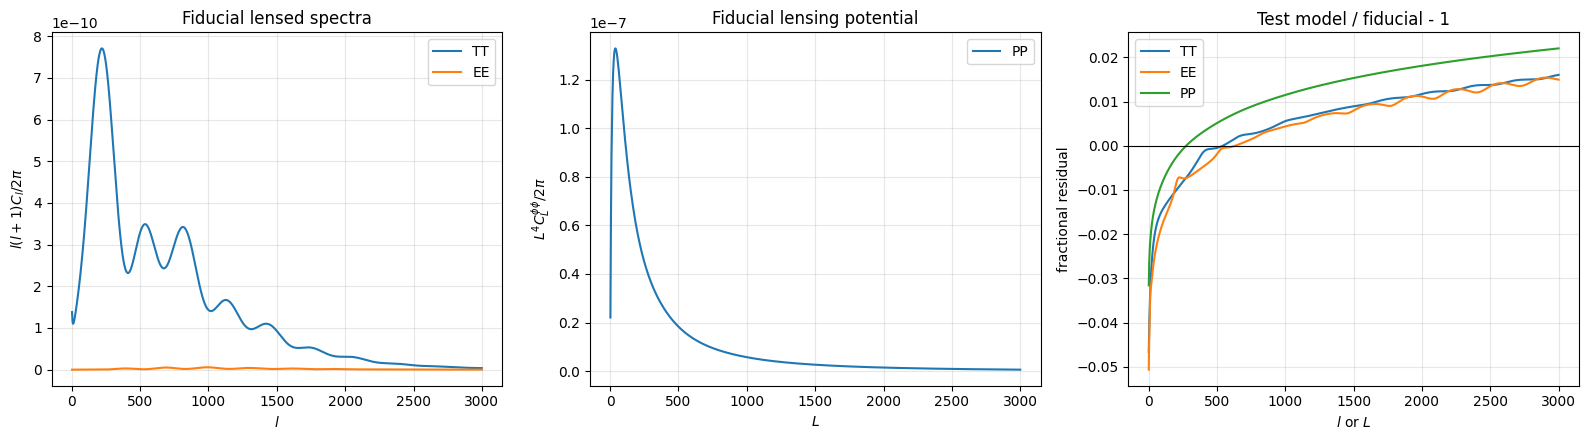

In [7]:
ells = fid_cls["ell"]
use = (ells >= experiment["l_min"]) & (ells <= experiment["l_max"])
dl_factor = ells * (ells + 1.0) / (2.0 * pi)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(ells[use], dl_factor[use] * fid_cls["tt"][use], label="TT")
axes[0].plot(ells[use], dl_factor[use] * fid_cls["ee"][use], label="EE")
axes[0].set_xlabel(r"$l$")
axes[0].set_ylabel(r"$l(l+1) C_l / 2\pi$")
axes[0].set_title("Fiducial lensed spectra")
axes[0].legend()
axes[0].grid(alpha=0.3)

use_pp = (ells >= experiment["l_min_pp"]) & (ells <= experiment["l_max_pp"])
axes[1].plot(ells[use_pp], (ells[use_pp] ** 4) * fid_cls["pp"][use_pp] / (2.0 * pi), label="PP")
axes[1].set_xlabel(r"$L$")
axes[1].set_ylabel(r"$L^4 C_L^{\phi\phi} / 2\pi$")
axes[1].set_title("Fiducial lensing potential")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ells[use], test_cls["tt"][use] / fid_cls["tt"][use] - 1.0, label="TT")
axes[2].plot(ells[use], test_cls["ee"][use] / fid_cls["ee"][use] - 1.0, label="EE")
axes[2].plot(ells[use_pp], test_cls["pp"][use_pp] / fid_cls["pp"][use_pp] - 1.0, label="PP")
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel(r"$l$ or $L$")
axes[2].set_ylabel("fractional residual")
axes[2].set_title("Test model / fiducial - 1")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

## Optional: matching MontePython `mock_cmb` configuration

If you later want to turn the same setup into a MontePython likelihood folder, the minimal class is the same as the existing `fake_planck_ede/fake_planck_realistic_ede/__init__.py`: subclass `Likelihood_mock_cmb` and put experiment settings in a `.data` file. For a CV-limited TT/TE/EE plus lensing mock, the important differences from the fake Planck example are zero instrumental/reconstruction noise and `f_sky = 1` unless you intentionally want partial sky.

In [8]:
montepython_init_py = """from montepython.likelihood_class import Likelihood_mock_cmb\n\n\nclass mock_cvl_cmb(Likelihood_mock_cmb):\n    pass\n"""

montepython_data = f"""# Mock cosmic-variance-limited CMB likelihood.\nmock_cvl_cmb.data_directory = data.path['data']\nmock_cvl_cmb.fiducial_file = 'mock_cvl_cmb_fiducial.dat'\n\nmock_cvl_cmb.l_min = {experiment['l_min']}\nmock_cvl_cmb.l_max = {experiment['l_max']}\nmock_cvl_cmb.l_min_lensing = {experiment['l_min_pp']}\nmock_cvl_cmb.l_max_lensing = {experiment['l_max_pp']}\nmock_cvl_cmb.f_sky = {experiment['f_sky']}\n\nmock_cvl_cmb.Bmodes = False\nmock_cvl_cmb.delensing = False\nmock_cvl_cmb.noise_from_file = False\n\nmock_cvl_cmb.LensingExtraction = {experiment['include_lensing_pp']}\nmock_cvl_cmb.neglect_TD = True\nmock_cvl_cmb.unlensed_clTTTEEE = False\nmock_cvl_cmb.ExcludeTTTEEE = False\n"""

print("__init__.py:\n")
print(montepython_init_py)
print("mock_cvl_cmb.data:\n")
print(montepython_data)

__init__.py:

from montepython.likelihood_class import Likelihood_mock_cmb


class mock_cvl_cmb(Likelihood_mock_cmb):
    pass

mock_cvl_cmb.data:

# Mock cosmic-variance-limited CMB likelihood.
mock_cvl_cmb.data_directory = data.path['data']
mock_cvl_cmb.fiducial_file = 'mock_cvl_cmb_fiducial.dat'

mock_cvl_cmb.l_min = 2
mock_cvl_cmb.l_max = 3000
mock_cvl_cmb.l_min_lensing = 2
mock_cvl_cmb.l_max_lensing = 3000
mock_cvl_cmb.f_sky = 1.0

mock_cvl_cmb.Bmodes = False
mock_cvl_cmb.delensing = False
mock_cvl_cmb.noise_from_file = False

mock_cvl_cmb.LensingExtraction = True
mock_cvl_cmb.neglect_TD = True
mock_cvl_cmb.unlensed_clTTTEEE = False
mock_cvl_cmb.ExcludeTTTEEE = False



# Generate spectra

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy_sz import Class as Class_sz
def l_to_dl(lp):
    return lp*(lp+1.)/2./np.pi

classy_sz = Class_sz()
classy_sz.initialize_classy_szfast()


%%time
cosmo_params = {
'omega_b': 0.02242,
'omega_cdm':  0.11933,
'H0': 67.66, # use H0 because this is what is used by the emulators and to avoid any ambiguity when comparing with camb.
'tau_reio': 0.0561,
'ln10^{10}A_s': 3.047,
'n_s': 0.9665
}


lensed_cls = classy_sz.get_cmb_cls(params_values_dict=cosmo_params)
l_fast = lensed_cls['ell']
cl_tt_fast = lensed_cls['tt']
cl_ee_fast = lensed_cls['ee']
cl_te_fast = lensed_cls['te']
cl_pp_fast = lensed_cls['pp']

label_size = 15
title_size = 20
legend_size = 13
handle_length = 1.5
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(18,5))

ax = ax1
ax.tick_params(axis = 'x',which='both',length=5,direction='in', pad=10)
ax.tick_params(axis = 'y',which='both',length=5,direction='in', pad=5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.setp(ax.get_yticklabels(), rotation='horizontal', fontsize=label_size)
plt.setp(ax.get_xticklabels(), fontsize=label_size)
ax.grid( visible=True, which="both", alpha=0.2, linestyle='--')


ax.plot(l_fast,l_to_dl(l_fast)*cl_tt_fast,ls='-.',label='class_szfast TT')


ax.plot(l_fast,l_to_dl(l_fast)*cl_ee_fast,ls='-.',c='red',label='class_szfast EE')



ax.set_ylabel(r"$D_\ell$",size=title_size)
ax.set_xlabel(r"$\ell$",size=title_size)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2,1e4)
ax.legend(fontsize=legend_size)


ax = ax2
ax.tick_params(axis = 'x',which='both',length=5,direction='in', pad=10)
ax.tick_params(axis = 'y',which='both',length=5,direction='in', pad=5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.setp(ax.get_yticklabels(), rotation='horizontal', fontsize=label_size)
plt.setp(ax.get_xticklabels(), fontsize=label_size)
ax.grid( visible=True, which="both", alpha=0.2, linestyle='--')



ax.plot(l_fast,l_to_dl(l_fast)*cl_te_fast,ls='-.',label='class_szfast TE')


ax.set_ylabel(r"$D_\ell^\mathrm{TE}$",size=title_size)
ax.set_xlabel(r"$\ell$",size=title_size)
ax.set_xscale('log')
ax.set_xlim(2,1e4)
ax.legend(fontsize=legend_size)


ax = ax3
ax.tick_params(axis = 'x',which='both',length=5,direction='in', pad=10)
ax.tick_params(axis = 'y',which='both',length=5,direction='in', pad=5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.setp(ax.get_yticklabels(), rotation='horizontal', fontsize=label_size)
plt.setp(ax.get_xticklabels(), fontsize=label_size)
ax.grid( visible=True, which="both", alpha=0.2, linestyle='--')


ax.plot(l_fast,l_to_dl(l_fast)*cl_pp_fast*(l_fast*(l_fast+1.)),ls='-.',label='class_szfast PP')

ax.set_ylabel(r"$[\ell(\ell+1)]^2 C_\ell^{\phi\phi}/2\pi$",size=title_size)
ax.set_xlabel(r"$\ell$",size=title_size)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2,1e4)
ax.legend(fontsize=legend_size)
fig.tight_layout()

In [9]:
l_fast

array([    0,     1,     2, ..., 19997, 19998, 19999], shape=(20000,))